In [1]:
!pip install opencv-python matplotlib numpy


[notice] A new release of pip available: 22.3.1 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


C:\Users\Admin\AppData\Local\Temp\ipykernel_31064\2811079563.py:33: RuntimeWarning: overflow encountered in scalar add
  c = 255 / np.log(1 + np.max(img))
C:\Users\Admin\AppData\Local\Temp\ipykernel_31064\2811079563.py:33: RuntimeWarning: divide by zero encountered in log
  c = 255 / np.log(1 + np.max(img))
C:\Users\Admin\AppData\Local\Temp\ipykernel_31064\2811079563.py:34: RuntimeWarning: divide by zero encountered in log
  log_transformed = c * np.log(1 + img)
C:\Users\Admin\AppData\Local\Temp\ipykernel_31064\2811079563.py:34: RuntimeWarning: invalid value encountered in multiply
  log_transformed = c * np.log(1 + img)
C:\Users\Admin\AppData\Local\Temp\ipykernel_31064\2811079563.py:35: RuntimeWarning: invalid value encountered in cast
  log_transformed = np.array(log_transformed, dtype=np.uint8)


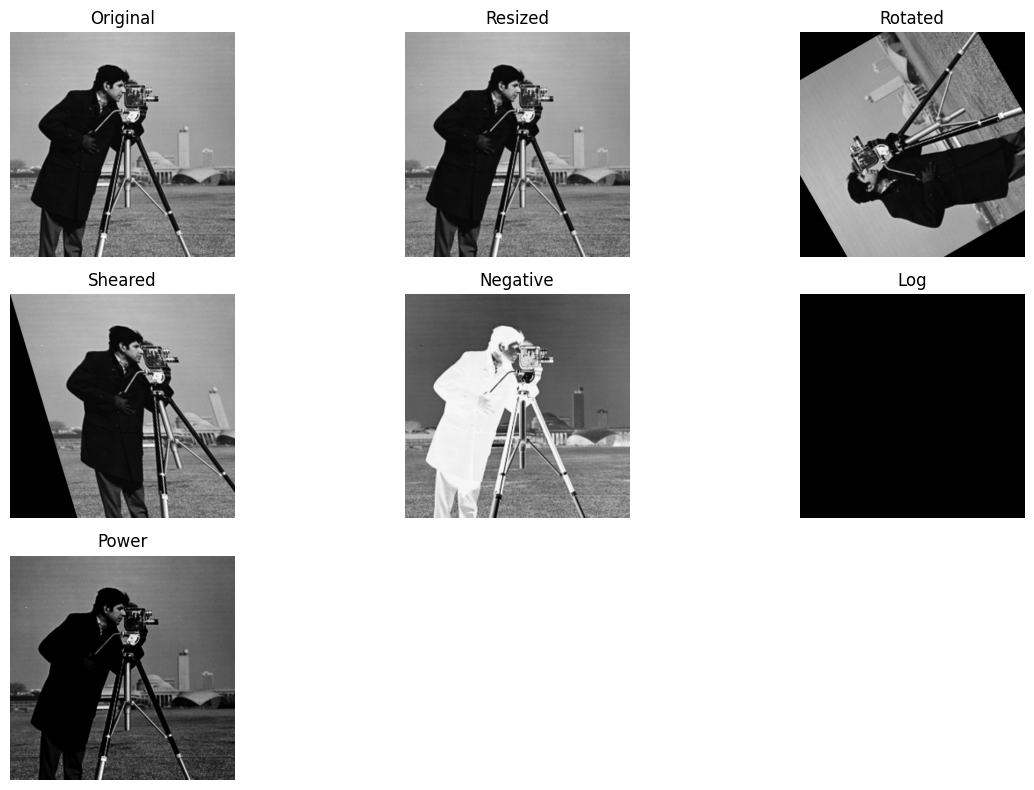

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Read image
img = cv2.imread(r'C:\Users\Admin\Downloads\cameraman.jpg') 
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Task 1: Geometric Transformations

# 1. Resize (increase size)
resized = cv2.resize(img, None, fx=1.5, fy=1.5)

# 2. Rotate 120 degrees
(h, w) = img.shape[:2]
center = (w // 2, h // 2)
M_rotate = cv2.getRotationMatrix2D(center, 120, 1.0)
rotated = cv2.warpAffine(img, M_rotate, (w, h))

# 3. Shear
shear_factor = 0.3
M_shear = np.float32([[1, shear_factor, 0],
                      [0, 1, 0]])
sheared = cv2.warpAffine(img, M_shear, (w, h))


# Task 2: Intensity Transformations

# 1. Negative
negative = 255 - img

# 2. Log Transformation
c = 255 / np.log(1 + np.max(img))
log_transformed = c * np.log(1 + img)
log_transformed = np.array(log_transformed, dtype=np.uint8)

# 3. Power Law (Gamma)
gamma = 2.0  # >1 increases contrast
power = np.array(255 * (img / 255) ** gamma, dtype='uint8')


# Show Results

titles = ['Original', 'Resized', 'Rotated', 'Sheared',
          'Negative', 'Log', 'Power']

images = [img, resized, rotated, sheared,
          negative, log_transformed, power]

plt.figure(figsize=(12,8))

for i in range(len(images)):
    plt.subplot(3,3,i+1)
    plt.imshow(images[i])
    plt.title(titles[i])
    plt.axis('off')

plt.tight_layout()
plt.show()